In [2]:
import jaxley

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


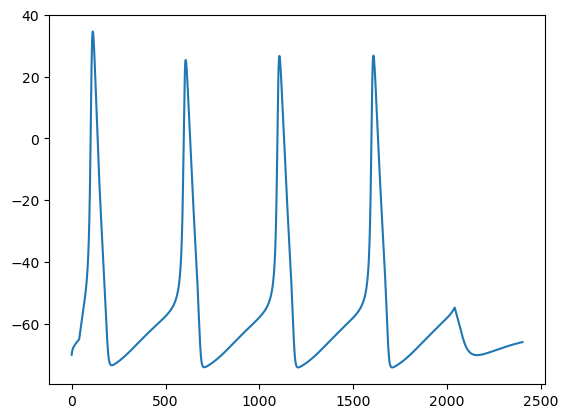

In [ ]:
import matplotlib.pyplot as plt
from jax import config

import jaxley as jx
from jaxley.channels import Na, K, Leak,  Km, CaL, CaT, HH

config.update("jax_platform_name", "gpu")  # Or "gpu" / "tpu".

cell = jx.Cell()  # Define cell.
cell.nodes.radius = 10.
cell.insert(HH())  # Insert Hodgkin-Huxley channels.
cell.insert(Na())
cell.insert(K())
cell.insert(Leak())
cell.insert(Km())
cell.insert(CaL())
cell.insert(CaT())


current = jx.step_current(i_delay=1.0, i_dur=50.0, i_amp=0.1, delta_t=0.025, t_max=60.0)
cell.stimulate(current)  # Stimulate with step current.
cell.record("v")  # Record voltage.

v = jx.integrate(cell)  # Run simulation.
plt.plot(v.T)  # Plot voltage trace.

In [60]:
cell.branch(0).nodes.columns

Index(['local_cell_index', 'local_branch_index', 'local_comp_index', 'length',
       'radius', 'axial_resistivity', 'capacitance', 'v', 'HH', 'HH_gNa',
       'HH_gK', 'HH_gLeak', 'HH_eNa', 'HH_eK', 'HH_eLeak', 'HH_m', 'HH_h',
       'HH_n', 'Na', 'Na_gNa', 'eNa', 'vt', 'Na_m', 'Na_h', 'K', 'K_gK', 'eK',
       'K_n', 'Leak', 'Leak_gLeak', 'Leak_eLeak', 'Km', 'Km_gKm', 'Km_taumax',
       'Km_p', 'CaL', 'CaL_gCaL', 'eCa', 'CaL_q', 'CaL_r', 'CaT', 'CaT_gCaT',
       'CaT_vx', 'CaT_u', 'global_cell_index', 'global_branch_index',
       'global_comp_index', 'controlled_by_param'],
      dtype='object')

In [64]:
cell.make_trainable("HH_gK")
cell.make_trainable("HH_gNa")
cell.make_trainable("HH_gLeak")

Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Number of newly added trainable parameters: 1. Total number of trainable parameters: 9
Number of newly added trainable parameters: 1. Total number of trainable parameters: 10


In [69]:
cell.nodes

,local_cell_index,local_branch_index,local_comp_index,length,radius,axial_resistivity,capacitance,v,global_cell_index,global_branch_index,...,HH,HH_gNa,HH_gK,HH_gLeak,HH_eNa,HH_eK,HH_eLeak,HH_m,HH_h,HH_n
0,0,0,0,10.0,10.0,5000.0,1.0,-70.0,0,0,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2


In [66]:
HH().channel_params

{'HH_gNa': 0.12,
 'HH_gK': 0.036,
 'HH_gLeak': 0.0003,
 'HH_eNa': 50.0,
 'HH_eK': -77.0,
 'HH_eLeak': -54.3}

In [67]:
Na().channel_params

{'Na_gNa': 0.05, 'eNa': 50.0, 'vt': -60.0}